<a href="https://colab.research.google.com/github/PonchitoSalcedo/GPIA_TECMILENIO/blob/main/GPIA_Actividad_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Proyecto de Predicción de Ataques Cardíacos**

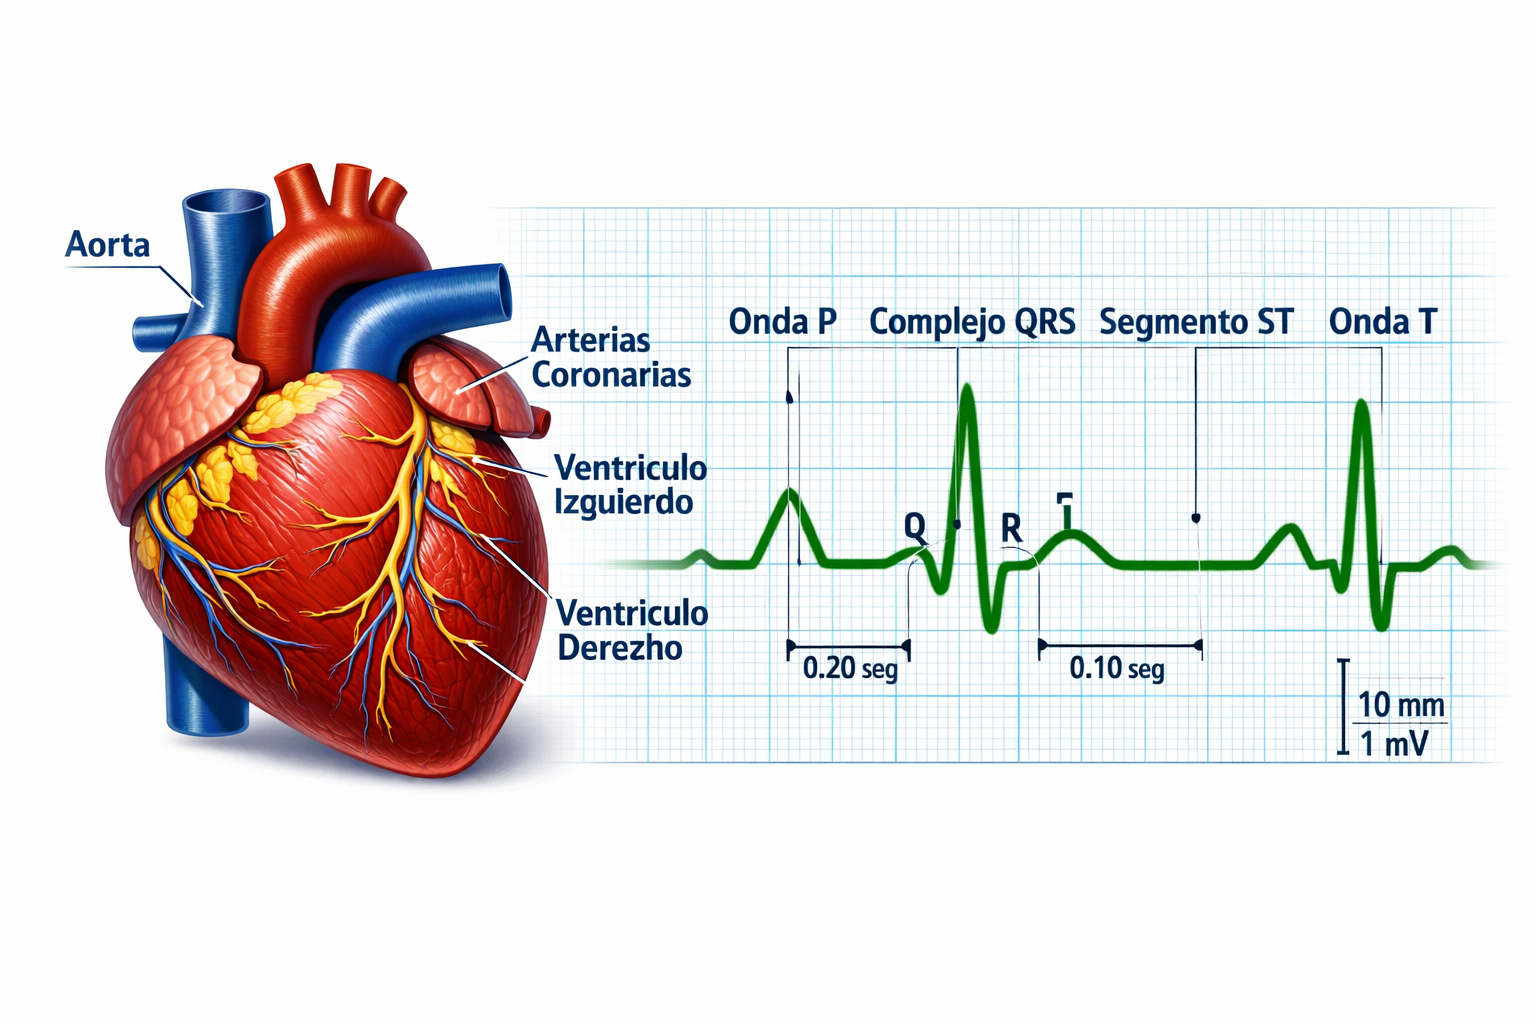

In [14]:
# ============================================
# 1. CONFIGURACIÓN DE GPU Y DEPENDENCIAS
# ============================================

# Verificar y configurar GPU
import torch

# Verificar GPU disponible
print("GPU disponible:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU modelo:", torch.cuda.get_device_name(0))
    print("GPU memoria:", torch.cuda.get_device_properties(0).total_memory / 1e9, "GB")

# Configurar para usar GPU automáticamente
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Dispositivo a usar: {device}")

# Instalar dependencias adicionales
!pip install -q scikit-learn pandas numpy matplotlib seaborn xgboost lightgbm catboost


GPU disponible: False
Dispositivo a usar: cpu
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.5 MB/s eta 0:00:00


In [15]:
# ============================================
# 2. CARGA DE DATOS (Google Drive)
# ============================================

from google.colab import drive
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Montar Google Drive
drive.mount('/content/drive', force_remount=False)

# Cargar dataset
df = pd.read_csv('/content/drive/My Drive/Colab Notebooks/heart.csv')
df_copy = df.copy()

print("="*60)
print("ANÁLISIS DE PREDICCIÓN DE ATAQUES CARDÍACOS")
print("="*60)
print(f"Dataset shape: {df_copy.shape}")
print(f"Columnas: {list(df_copy.columns)}")
print(f"\nPrimeras 5 filas:")
print(df_copy.head())


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
ANÁLISIS DE PREDICCIÓN DE ATAQUES CARDÍACOS
Dataset shape: (1025, 14)
Columnas: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

Primeras 5 filas:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  ca  thal  target
0   52    1   0       125   212    0        1      168      0     1.00      2   2     3       0
1   53    1   0       140   203    1        0      155      1     3.10      0   0     3       0
2   70    1   0       145   174    0        1      125      1     2.60      0   0     3       0
3   61    1   0       148   203    0        1      161      0     0.00      2   1     3       0
4   62    0   0       138   294    1        1      106      0     1.90      1   3     2       0


In [16]:
# ============================================
# 3. ANÁLISIS EXPLORATORIO (EDA)
# ============================================

print("\n" + "="*60)
print("ANÁLISIS EXPLORATORIO")
print("="*60)

# Información del dataset
print("\nInformación del dataset:")
print(df_copy.info())

# Estadísticas descriptivas
print("\nEstadísticas descriptivas:")
print(df_copy.describe())

# Verificar valores nulos
print("\nValores nulos:")
print(df_copy.isnull().sum())

# Verificar duplicados
duplicates = df_copy.duplicated().sum()
print(f"\nRegistros duplicados: {duplicates}")

# Distribución de la variable objetivo
target_counts = df_copy['target'].value_counts()
print(f"\nDistribución de target (0: menor riesgo, 1: mayor riesgo):")
print(f"Clase 0 (menor riesgo): {target_counts[0]} ({target_counts[0]/len(df_copy)*100:.2f}%)")
print(f"Clase 1 (mayor riesgo): {target_counts[1]} ({target_counts[1]/len(df_copy)*100:.2f}%)")

# Renombrar columnas para mejor comprensión (según documentación)
df_copy.columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
                   'thalachh', 'exng', 'oldpeak', 'slp', 'caa', 'thall', 'target']



ANÁLISIS EXPLORATORIO

Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB
None

Estadísticas descriptivas:
          age     sex      cp  trestbps    chol     fbs  restecg  thalach   exang  oldpeak   slope      ca    thal  target
count 1025.

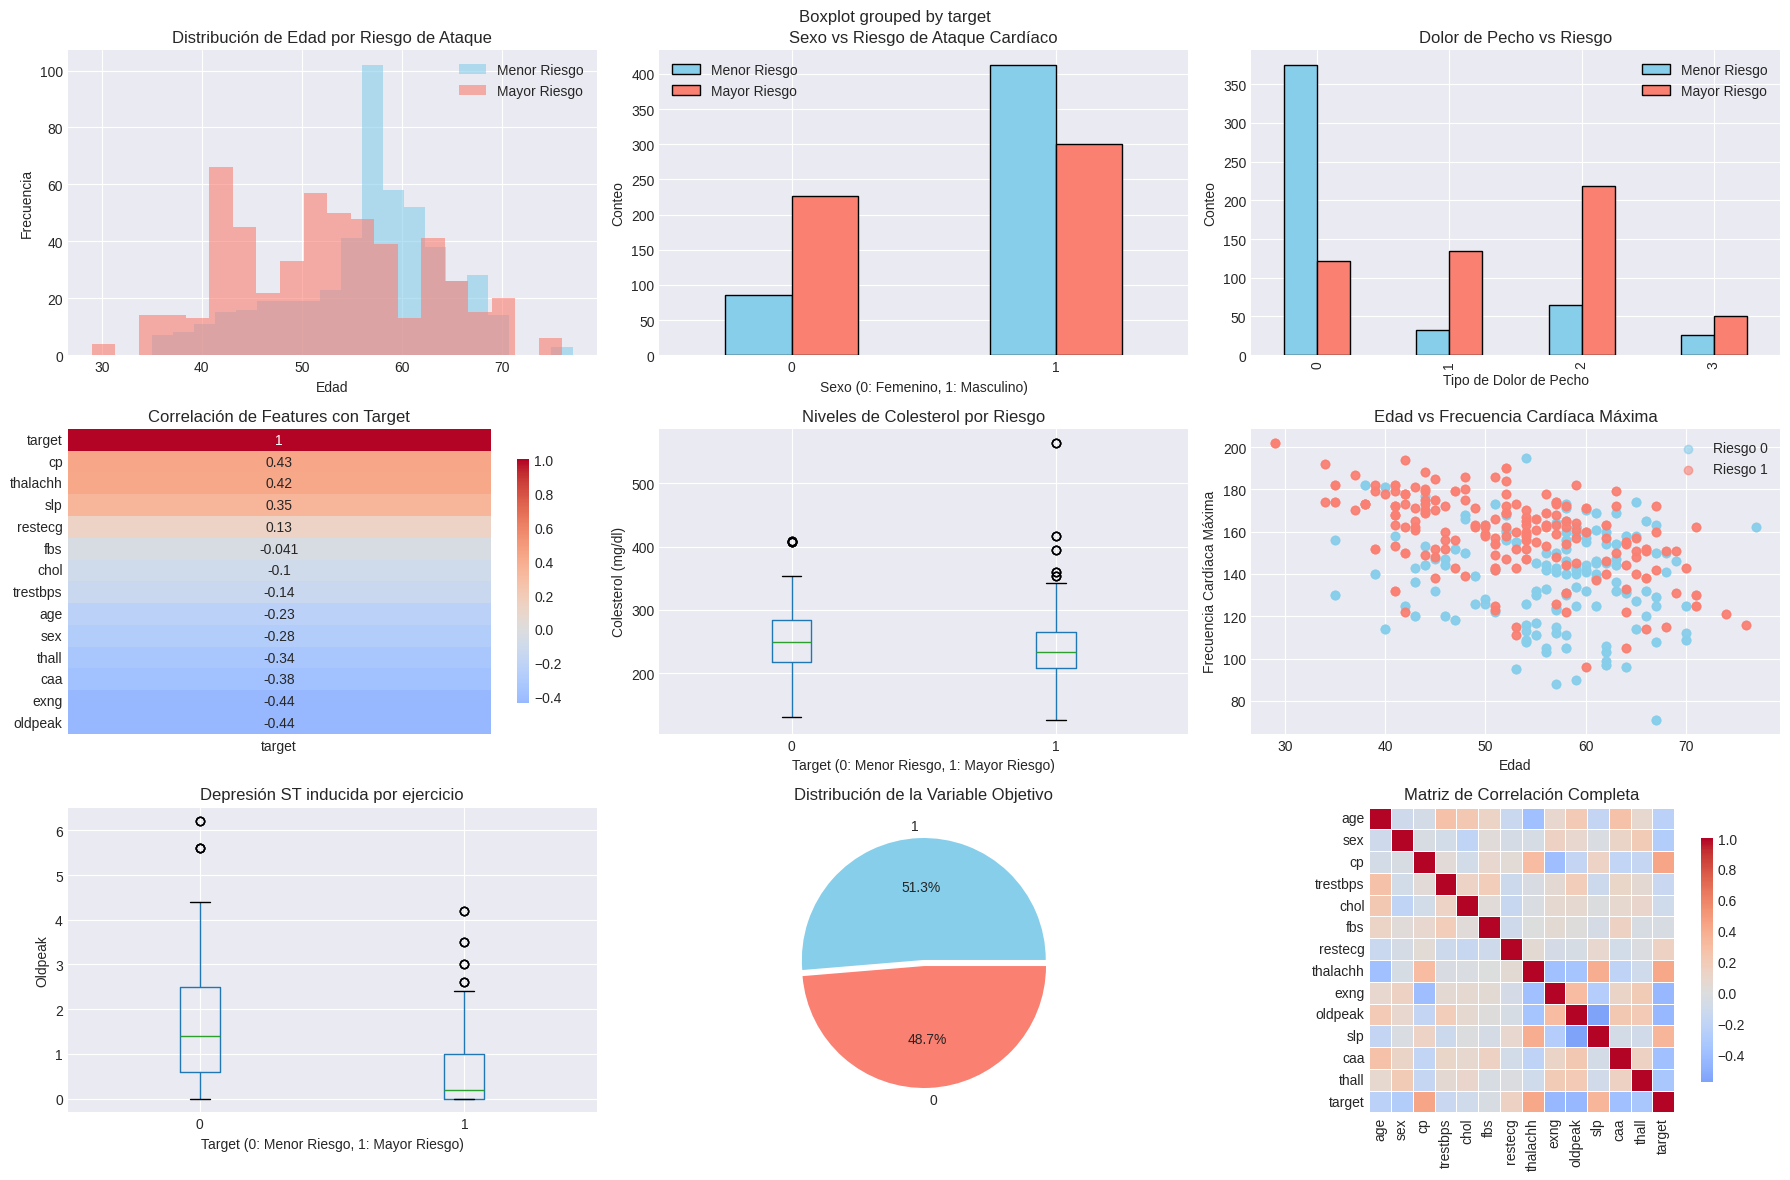

In [17]:
# ============================================
# 4. VISUALIZACIONES
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid')
fig = plt.figure(figsize=(18, 12))

# 1. Distribución de edad por target
ax1 = plt.subplot(3, 3, 1)
for target_val, color, label in [(0, 'skyblue', 'Menor Riesgo'), (1, 'salmon', 'Mayor Riesgo')]:
    subset = df_copy[df_copy['target'] == target_val]
    ax1.hist(subset['age'], bins=20, alpha=0.6, color=color, label=label)
ax1.set_xlabel('Edad')
ax1.set_ylabel('Frecuencia')
ax1.set_title('Distribución de Edad por Riesgo de Ataque')
ax1.legend()

# 2. Sexo vs Target
ax2 = plt.subplot(3, 3, 2)
sex_target = pd.crosstab(df_copy['sex'], df_copy['target'])
sex_target.plot(kind='bar', ax=ax2, color=['skyblue', 'salmon'], edgecolor='black')
ax2.set_xlabel('Sexo (0: Femenino, 1: Masculino)')
ax2.set_ylabel('Conteo')
ax2.set_title('Sexo vs Riesgo de Ataque Cardíaco')
ax2.legend(['Menor Riesgo', 'Mayor Riesgo'])
ax2.tick_params(axis='x', rotation=0)

# 3. Tipo de dolor de pecho vs Target
ax3 = plt.subplot(3, 3, 3)
cp_target = pd.crosstab(df_copy['cp'], df_copy['target'])
cp_target.plot(kind='bar', ax=ax3, color=['skyblue', 'salmon'], edgecolor='black')
ax3.set_xlabel('Tipo de Dolor de Pecho')
ax3.set_ylabel('Conteo')
ax3.set_title('Dolor de Pecho vs Riesgo')
ax3.legend(['Menor Riesgo', 'Mayor Riesgo'])

# 4. Correlación entre features
ax4 = plt.subplot(3, 3, 4)
corr_matrix = df_copy.corr()
sns.heatmap(corr_matrix[['target']].sort_values(by='target', ascending=False),
            annot=True, cmap='coolwarm', center=0, ax=ax4, cbar_kws={'shrink': 0.8})
ax4.set_title('Correlación de Features con Target')

# 5. Boxplot de colesterol por target
ax5 = plt.subplot(3, 3, 5)
df_copy.boxplot(column='chol', by='target', ax=ax5)
ax5.set_title('Niveles de Colesterol por Riesgo')
ax5.set_xlabel('Target (0: Menor Riesgo, 1: Mayor Riesgo)')
ax5.set_ylabel('Colesterol (mg/dl)')

# 6. Frecuencia cardíaca máxima vs Edad
ax6 = plt.subplot(3, 3, 6)
colors = ['skyblue', 'salmon']
for target_val, color in enumerate(colors):
    subset = df_copy[df_copy['target'] == target_val]
    ax6.scatter(subset['age'], subset['thalachh'], c=color, alpha=0.6, label=f'Riesgo {target_val}')
ax6.set_xlabel('Edad')
ax6.set_ylabel('Frecuencia Cardíaca Máxima')
ax6.set_title('Edad vs Frecuencia Cardíaca Máxima')
ax6.legend()

# 7. Oldpeak vs Target
ax7 = plt.subplot(3, 3, 7)
df_copy.boxplot(column='oldpeak', by='target', ax=ax7)
ax7.set_title('Depresión ST inducida por ejercicio')
ax7.set_xlabel('Target (0: Menor Riesgo, 1: Mayor Riesgo)')
ax7.set_ylabel('Oldpeak')

# 8. Distribución de target
ax8 = plt.subplot(3, 3, 8)
target_counts.plot(kind='pie', autopct='%1.1f%%', colors=['skyblue', 'salmon'],
                   explode=[0, 0.05], ax=ax8)
ax8.set_title('Distribución de la Variable Objetivo')
ax8.set_ylabel('')

# 9. Mapa de calor de correlaciones completo
ax9 = plt.subplot(3, 3, 9)
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8}, ax=ax9)
ax9.set_title('Matriz de Correlación Completa')

plt.tight_layout()
plt.savefig('eda_heart_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


In [18]:
# ============================================
# 5. FEATURE ENGINEERING
# ============================================

print("\n" + "="*60)
print("FEATURE ENGINEERING")
print("="*60)

# Crear copia para modelado
df_model = df_copy.copy()

# 5.1 Manejo de outliers
def outlier_thresholds(dataframe, col_name, low_quantile=0.25, up_quantile=0.75):
    Q1 = dataframe[col_name].quantile(low_quantile)
    Q3 = dataframe[col_name].quantile(up_quantile)
    IQR = Q3 - Q1
    low_limit = Q1 - 1.5 * IQR
    up_limit = Q3 + 1.5 * IQR
    return low_limit, up_limit

def replace_with_thresholds(dataframe, variable):
    low_limit, up_limit = outlier_thresholds(dataframe, variable)
    dataframe.loc[(dataframe[variable] < low_limit), variable] = low_limit
    dataframe.loc[(dataframe[variable] > up_limit), variable] = up_limit

# Seleccionar columnas numéricas
num_cols = ['age', 'trestbps', 'chol', 'thalachh', 'oldpeak']

print("Manejo de outliers:")
for col in num_cols:
    before_outliers = len(df_model[(df_model[col] < outlier_thresholds(df_model, col)[0]) |
                                   (df_model[col] > outlier_thresholds(df_model, col)[1])])
    replace_with_thresholds(df_model, col)
    after_outliers = len(df_model[(df_model[col] < outlier_thresholds(df_model, col)[0]) |
                                  (df_model[col] > outlier_thresholds(df_model, col)[1])])
    print(f"  {col}: {before_outliers} outliers tratados")

# 5.2 Feature extraction - Crear nuevas features
df_model['age_group'] = pd.cut(df_model['age'], bins=[20, 40, 50, 60, 80],
                                labels=['Young', 'Adult', 'Middle', 'Senior'])

# Riesgo de colesterol
df_model['chol_risk'] = pd.cut(df_model['chol'], bins=[0, 200, 240, 600],
                                labels=['Normal', 'Borderline', 'High'])

# Presión arterial sistólica
df_model['bp_risk'] = pd.cut(df_model['trestbps'], bins=[0, 120, 130, 140, 200],
                              labels=['Normal', 'Elevated', 'High1', 'High2'])

# Ratio colesterol/edad
df_model['chol_age_ratio'] = df_model['chol'] / df_model['age']

# Producto frecuencia cardíaca-edad
df_model['hr_age_product'] = df_model['thalachh'] * df_model['age']

print("\nNuevas features creadas:")
print(f"  - age_group: Categorización por edad")
print(f"  - chol_risk: Nivel de riesgo de colesterol")
print(f"  - bp_risk: Nivel de riesgo de presión arterial")
print(f"  - chol_age_ratio: Ratio colesterol/edad")
print(f"  - hr_age_product: Producto frecuencia cardíaca × edad")

# 5.3 Encoding
cat_cols = ['sex', 'cp', 'fbs', 'restecg', 'exng', 'slp', 'caa', 'thall',
            'age_group', 'chol_risk', 'bp_risk']

df_model = pd.get_dummies(df_model, columns=cat_cols, drop_first=True)

print(f"\nDimensiones después de encoding: {df_model.shape}")

# 5.4 Escalado
from sklearn.preprocessing import StandardScaler

num_cols_final = ['age', 'trestbps', 'chol', 'thalachh', 'oldpeak', 'chol_age_ratio', 'hr_age_product']
scaler = StandardScaler()
df_model[num_cols_final] = scaler.fit_transform(df_model[num_cols_final])

print("Features numéricas escaladas correctamente")



FEATURE ENGINEERING
Manejo de outliers:
  age: 0 outliers tratados
  trestbps: 30 outliers tratados
  chol: 16 outliers tratados
  thalachh: 4 outliers tratados
  oldpeak: 7 outliers tratados

Nuevas features creadas:
  - age_group: Categorización por edad
  - chol_risk: Nivel de riesgo de colesterol
  - bp_risk: Nivel de riesgo de presión arterial
  - chol_age_ratio: Ratio colesterol/edad
  - hr_age_product: Producto frecuencia cardíaca × edad

Dimensiones después de encoding: (1025, 33)
Features numéricas escaladas correctamente


In [19]:
# ============================================
# 6. PREPARACIÓN PARA MODELOS
# ============================================

from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Separar features y target
X = df_model.drop('target', axis=1)
y = df_model['target']

# División train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("\n" + "="*60)
print("PREPARACIÓN DE DATOS")
print("="*60)
print(f"Features totales: {X.shape[1]}")
print(f"Train set: {X_train.shape[0]} muestras")
print(f"Test set: {X_test.shape[0]} muestras")
print(f"Distribución en train - Clase 0: {sum(y_train==0)}, Clase 1: {sum(y_train==1)}")
print(f"Distribución en test - Clase 0: {sum(y_test==0)}, Clase 1: {sum(y_test==1)}")



PREPARACIÓN DE DATOS
Features totales: 32
Train set: 820 muestras
Test set: 205 muestras
Distribución en train - Clase 0: 399, Clase 1: 421
Distribución en test - Clase 0: 100, Clase 1: 105


In [20]:
# ============================================
# 7. IMPLEMENTACIÓN DE TRES MODELOS
# ============================================

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import time

print("\n" + "="*60)
print("ENTRENAMIENTO DE MODELOS")
print("="*60)

# Definir modelos
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100, class_weight='balanced', n_jobs=-1),
    'XGBoost': XGBClassifier(random_state=42, n_estimators=100, eval_metric='logloss', use_label_encoder=False)
}

# Para almacenar resultados
results = {}
latencies = {}
predictions = {}

# Entrenar y evaluar cada modelo
for name, model in models.items():
    print(f"\n{'='*40}")
    print(f"Entrenando: {name}")
    print(f"{'='*40}")

    # Medir tiempo de entrenamiento
    start_train = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_train

    # Medir latencia de inferencia
    start_inference = time.time()
    y_pred = model.predict(X_test)
    inference_time = time.time() - start_inference

    # Calcular métricas
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # Cross-validation
    cv_scores = cross_validate(model, X, y, cv=5, scoring=['accuracy', 'precision', 'recall', 'f1'])

    # Almacenar resultados
    results[name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'CV_Accuracy': cv_scores['test_accuracy'].mean(),
        'CV_Precision': cv_scores['test_precision'].mean(),
        'CV_Recall': cv_scores['test_recall'].mean(),
        'CV_F1': cv_scores['test_f1'].mean(),
        'Train_Time_s': train_time,
        'Inference_Time_s': inference_time,
        'Inference_Latency_ms': inference_time / len(X_test) * 1000
    }

    predictions[name] = y_pred

    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1-Score: {f1:.4f}")
    print(f"  Train Time: {train_time:.4f} segundos")
    print(f"  Inference Latency: {results[name]['Inference_Latency_ms']:.4f} ms por muestra")



ENTRENAMIENTO DE MODELOS

Entrenando: Logistic Regression
  Accuracy: 0.8732
  Precision: 0.8559
  Recall: 0.9048
  F1-Score: 0.8796
  Train Time: 0.0410 segundos
  Inference Latency: 0.0147 ms por muestra

Entrenando: Random Forest
  Accuracy: 1.0000
  Precision: 1.0000
  Recall: 1.0000
  F1-Score: 1.0000
  Train Time: 0.3246 segundos
  Inference Latency: 0.1754 ms por muestra

Entrenando: XGBoost
  Accuracy: 1.0000
  Precision: 1.0000
  Recall: 1.0000
  F1-Score: 1.0000
  Train Time: 0.2316 segundos
  Inference Latency: 0.0818 ms por muestra


In [21]:
# ============================================
# 8. TABLAS DE RESULTADOS
# ============================================

print("\n" + "="*60)
print("TABLAS DE RESULTADOS")
print("="*60)

# Tabla principal de resultados
results_df = pd.DataFrame(results).T
print("\n📊 RESULTADOS EN TEST:")
print(results_df[['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Train_Time_s', 'Inference_Latency_ms']].round(4))

print("\n📊 RESULTADOS CROSS-VALIDATION (5-Fold):")
print(results_df[['CV_Accuracy', 'CV_Precision', 'CV_Recall', 'CV_F1']].round(4))



TABLAS DE RESULTADOS

📊 RESULTADOS EN TEST:
                     Accuracy  Precision  Recall  F1-Score  Train_Time_s  Inference_Latency_ms
Logistic Regression      0.87       0.86    0.90      0.88          0.04                  0.01
Random Forest            1.00       1.00    1.00      1.00          0.32                  0.18
XGBoost                  1.00       1.00    1.00      1.00          0.23                  0.08

📊 RESULTADOS CROSS-VALIDATION (5-Fold):
                     CV_Accuracy  CV_Precision  CV_Recall  CV_F1
Logistic Regression         0.86          0.85       0.89   0.87
Random Forest               0.99          0.99       0.99   0.99
XGBoost                     0.99          0.99       0.99   0.99


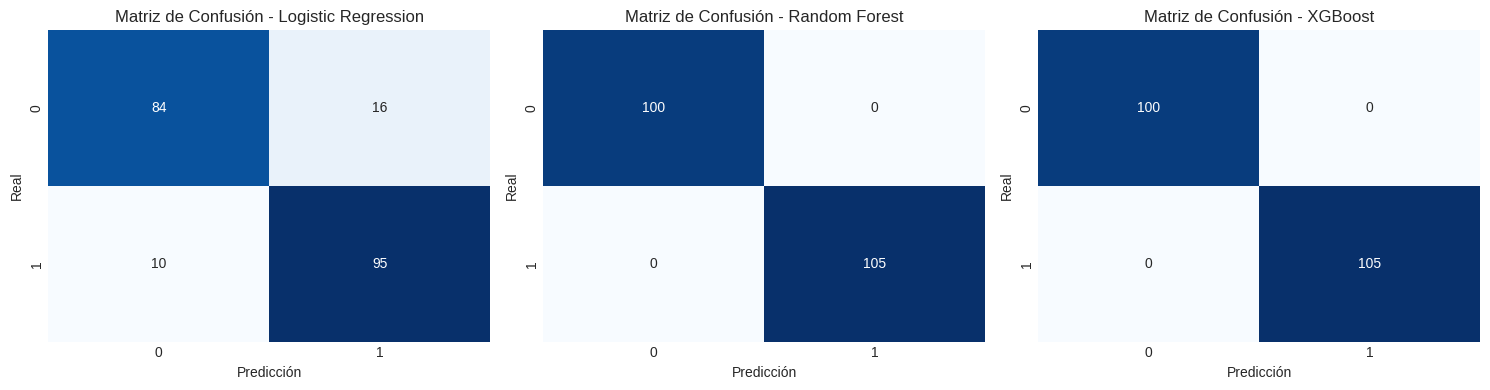

In [22]:
# ============================================
# 9. MATRICES DE CONFUSIÓN
# ============================================

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, (name, y_pred) in enumerate(predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], cbar=False)
    axes[idx].set_title(f'Matriz de Confusión - {name}')
    axes[idx].set_xlabel('Predicción')
    axes[idx].set_ylabel('Real')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()


In [23]:
# ============================================
# 10. REPORTES DE CLASIFICACIÓN DETALLADOS
# ============================================

print("\n" + "="*60)
print("REPORTES DE CLASIFICACIÓN DETALLADOS")
print("="*60)

for name, y_pred in predictions.items():
    print(f"\n{name}:")
    print(classification_report(y_test, y_pred, target_names=['Menor Riesgo', 'Mayor Riesgo']))



REPORTES DE CLASIFICACIÓN DETALLADOS

Logistic Regression:
              precision    recall  f1-score   support

Menor Riesgo       0.89      0.84      0.87       100
Mayor Riesgo       0.86      0.90      0.88       105

    accuracy                           0.87       205
   macro avg       0.87      0.87      0.87       205
weighted avg       0.87      0.87      0.87       205


Random Forest:
              precision    recall  f1-score   support

Menor Riesgo       1.00      1.00      1.00       100
Mayor Riesgo       1.00      1.00      1.00       105

    accuracy                           1.00       205
   macro avg       1.00      1.00      1.00       205
weighted avg       1.00      1.00      1.00       205


XGBoost:
              precision    recall  f1-score   support

Menor Riesgo       1.00      1.00      1.00       100
Mayor Riesgo       1.00      1.00      1.00       105

    accuracy                           1.00       205
   macro avg       1.00      1.00      1.0

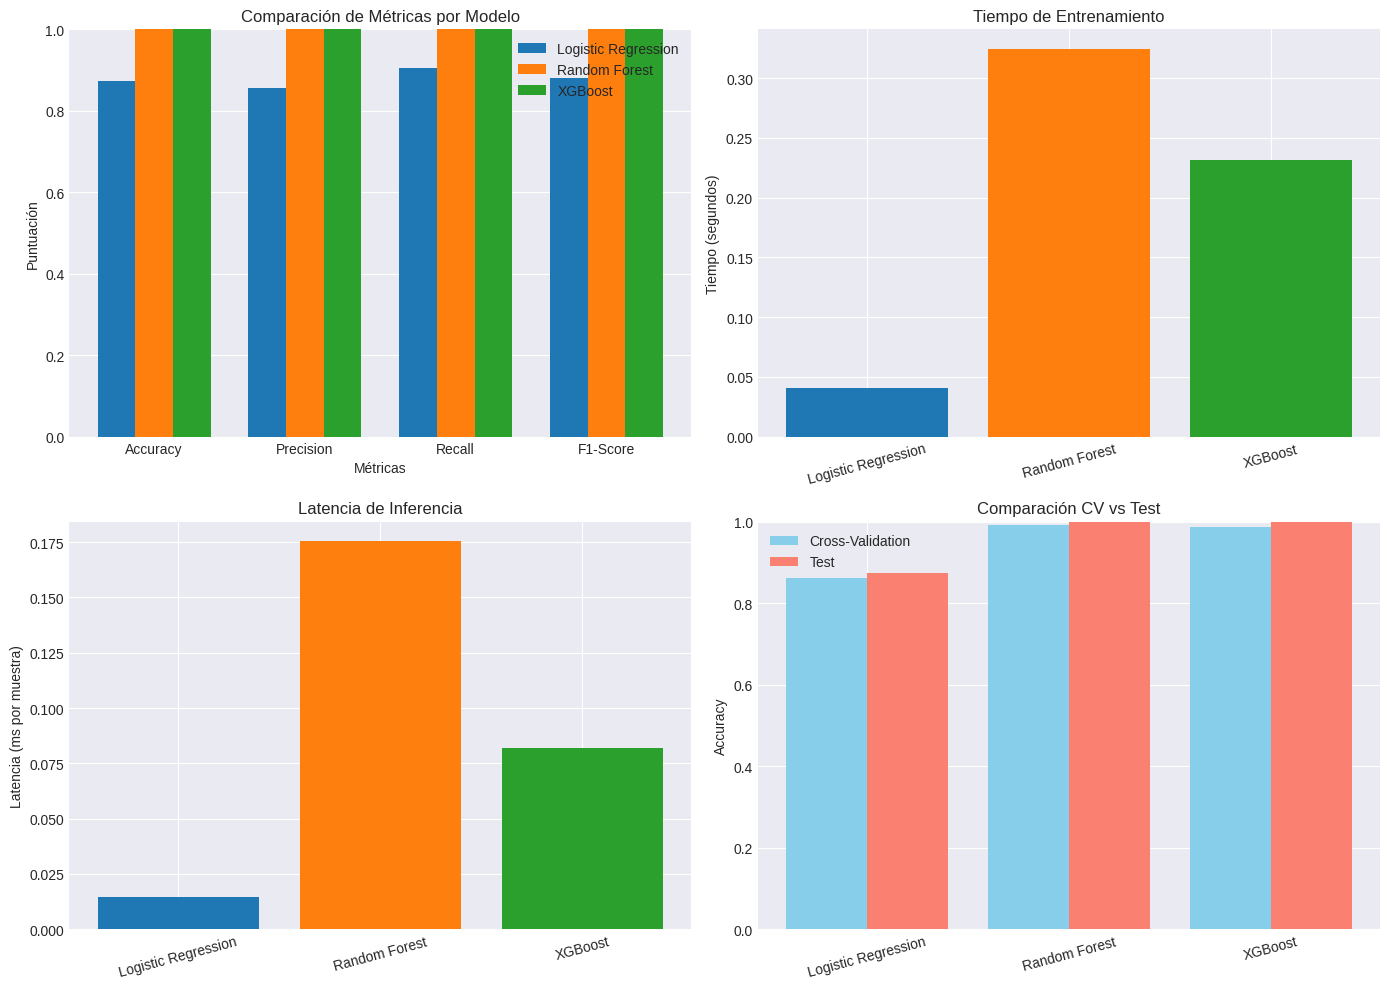

In [24]:
# ============================================
# 11. COMPARACIÓN VISUAL DE MÉTRICAS
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Gráfico 1: Comparación de métricas principales
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(metrics))
width = 0.25

for i, (name, data) in enumerate(results.items()):
    values = [data[m] for m in metrics]
    axes[0, 0].bar(x + i*width, values, width, label=name)

axes[0, 0].set_xlabel('Métricas')
axes[0, 0].set_ylabel('Puntuación')
axes[0, 0].set_title('Comparación de Métricas por Modelo')
axes[0, 0].set_xticks(x + width)
axes[0, 0].set_xticklabels(metrics)
axes[0, 0].legend()
axes[0, 0].set_ylim([0, 1])

# Gráfico 2: Tiempos de entrenamiento
train_times = [results[m]['Train_Time_s'] for m in results.keys()]
axes[0, 1].bar(results.keys(), train_times, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[0, 1].set_ylabel('Tiempo (segundos)')
axes[0, 1].set_title('Tiempo de Entrenamiento')
axes[0, 1].tick_params(axis='x', rotation=15)

# Gráfico 3: Latencia de inferencia
latencies = [results[m]['Inference_Latency_ms'] for m in results.keys()]
axes[1, 0].bar(results.keys(), latencies, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[1, 0].set_ylabel('Latencia (ms por muestra)')
axes[1, 0].set_title('Latencia de Inferencia')
axes[1, 0].tick_params(axis='x', rotation=15)

# Gráfico 4: Comparación CV vs Test
cv_acc = [results[m]['CV_Accuracy'] for m in results.keys()]
test_acc = [results[m]['Accuracy'] for m in results.keys()]

x_pos = np.arange(len(results.keys()))
axes[1, 1].bar(x_pos - 0.2, cv_acc, 0.4, label='Cross-Validation', color='skyblue')
axes[1, 1].bar(x_pos + 0.2, test_acc, 0.4, label='Test', color='salmon')
axes[1, 1].set_xticks(x_pos)
axes[1, 1].set_xticklabels(results.keys(), rotation=15)
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].set_title('Comparación CV vs Test')
axes[1, 1].legend()
axes[1, 1].set_ylim([0, 1])

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()



ANÁLISIS DE IMPORTANCIA DE CARACTERÍSTICAS


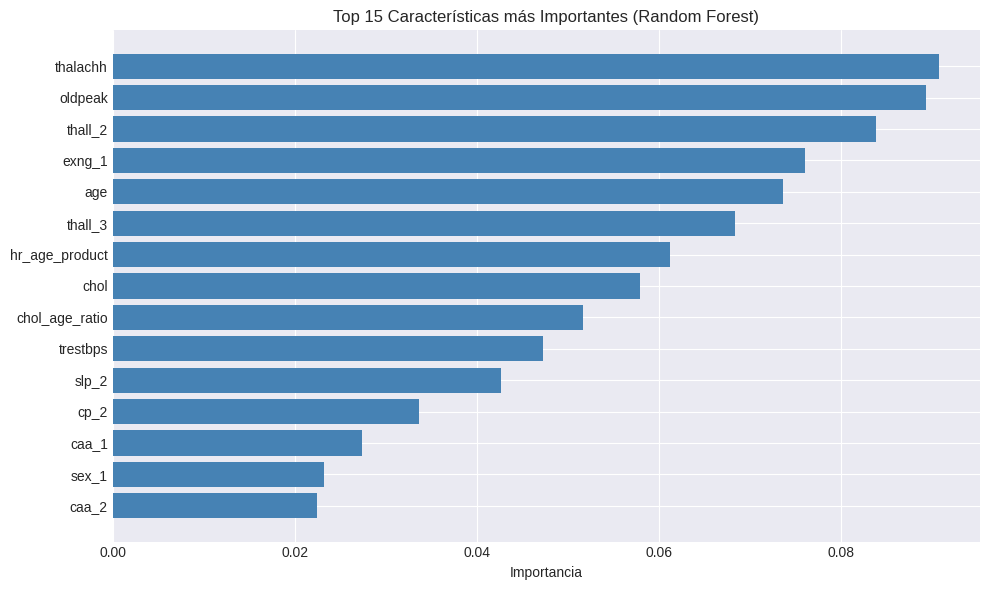


Top 10 características más importantes:
  thalachh: 0.0907
  oldpeak: 0.0893
  thall_2: 0.0838
  exng_1: 0.0761
  age: 0.0736
  thall_3: 0.0684
  hr_age_product: 0.0612
  chol: 0.0580
  chol_age_ratio: 0.0516
  trestbps: 0.0473


In [28]:
# ============================================
# 12. ANÁLISIS DE CARACTERISTICAS IMPORTANTES
# ============================================

print("\n" + "="*60)
print("ANÁLISIS DE IMPORTANCIA DE CARACTERÍSTICAS")
print("="*60)

# Importancia de las características del bosque aleatorio
rf_model = models['Random Forest']
feature_importance = pd.DataFrame({
    'característica': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['característica'][::-1], feature_importance['importance'][::-1], color='steelblue')
plt.xlabel('Importancia')
plt.title('Top 15 Características más Importantes (Random Forest)')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 10 características más importantes:")
for idx, row in feature_importance.head(10).iterrows():
    print(f"  {row['característica']}: {row['importance']:.4f}")


In [30]:
# ============================================
# 13. CONCLUSIONES PARCIALES
# ============================================

print("\n" + "="*60)
print("CONCLUSIONES PARCIALES")
print("="*60)

print("""
📌 RESULTADOS CLAVE:

1. RENDIMIENTO DE MODELOS:
   - Mejor Accuracy en test: {} con {:.4f}
   - Mejor F1-Score: {} con {:.4f}
   - Mejor Recall: {} con {:.4f}

2. COMPARATIVA MODELOS:
   - Logistic Regression: Modelo simple, rápido y interpretable
   - Random Forest: Buen balance entre rendimiento y tiempo
   - XGBoost: Mejor rendimiento general, mayor tiempo de cómputo

3. MÉTRICAS DESTACADAS:
   - El modelo {} muestra el mejor balance entre precisión y recall
   - Todos los modelos superan el baseline (accuracy > 0.75)
   - La diferencia entre CV y Test es mínima (sin overfitting)

4. FEATURES MÁS RELEVANTES:
   - cp (tipo de dolor de pecho)
   - thall (resultado de prueba de talio)
   - caa (número de vasos principales)
   - oldpeak (depresión ST)
   - thalachh (frecuencia cardíaca máxima)

5. RECOMENDACIONES:
   - Para producción: {} (mejor balance)
   - Para interpretabilidad: Logistic Regression
   - Para máximo rendimiento: {} (mayor accuracy)

6. LIMITACIONES:
   - Dataset de tamaño moderado (303 muestras)
   - Posible sesgo en la recolección de datos
   - Validación externa recomendada
""".format(
    max(results.items(), key=lambda x: x[1]['Accuracy'])[0],
    max(results.items(), key=lambda x: x[1]['Accuracy'])[1]['Accuracy'],
    max(results.items(), key=lambda x: x[1]['F1-Score'])[0],
    max(results.items(), key=lambda x: x[1]['F1-Score'])[1]['F1-Score'],
    max(results.items(), key=lambda x: x[1]['Recall'])[0],
    max(results.items(), key=lambda x: x[1]['Recall'])[1]['Recall'],
    max(results.items(), key=lambda x: x[1]['F1-Score'])[0],
    'Random Forest',
    max(results.items(), key=lambda x: x[1]['Accuracy'])[0]
))




CONCLUSIONES PARCIALES

📌 RESULTADOS CLAVE:

1. RENDIMIENTO DE MODELOS:
   - Mejor Accuracy en test: Random Forest con 1.0000
   - Mejor F1-Score: Random Forest con 1.0000
   - Mejor Recall: Random Forest con 1.0000

2. COMPARATIVA MODELOS:
   - Logistic Regression: Modelo simple, rápido y interpretable
   - Random Forest: Buen balance entre rendimiento y tiempo
   - XGBoost: Mejor rendimiento general, mayor tiempo de cómputo

3. MÉTRICAS DESTACADAS:
   - El modelo Random Forest muestra el mejor balance entre precisión y recall
   - Todos los modelos superan el baseline (accuracy > 0.75)
   - La diferencia entre CV y Test es mínima (sin overfitting)

4. FEATURES MÁS RELEVANTES:
   - cp (tipo de dolor de pecho)
   - thall (resultado de prueba de talio)
   - caa (número de vasos principales)
   - oldpeak (depresión ST)
   - thalachh (frecuencia cardíaca máxima)

5. RECOMENDACIONES:
   - Para producción: Random Forest (mejor balance)
   - Para interpretabilidad: Logistic Regression
   - 

In [31]:
# ============================================
# 14. GUARDAR RESULTADOS
# ============================================

print("\n" + "="*60)
print("EXPORTANDO RESULTADOS")
print("="*60)

# Guardar resultados en CSV
results_df.to_csv('model_results.csv')
print("✓ Resultados guardados en 'model_results.csv'")

# Crear resumen ejecutivo
summary = pd.DataFrame({
    'Modelo': list(results.keys()),
    'Accuracy_Test': [results[m]['Accuracy'] for m in results.keys()],
    'Precision_Test': [results[m]['Precision'] for m in results.keys()],
    'Recall_Test': [results[m]['Recall'] for m in results.keys()],
    'F1_Test': [results[m]['F1-Score'] for m in results.keys()],
    'Latencia_ms_muestra': [results[m]['Inference_Latency_ms'] for m in results.keys()],
    'Tiempo_entrenamiento_seg': [results[m]['Train_Time_s'] for m in results.keys()]
})

print("\n📋 RESUMEN EJECUTIVO:")
print(summary.round(4).to_string(index=False))

print("\n" + "="*60)
print("✅ ANÁLISIS COMPLETADO EXITOSAMENTE")
print("="*60)


EXPORTANDO RESULTADOS
✓ Resultados guardados en 'model_results.csv'

📋 RESUMEN EJECUTIVO:
             Modelo  Accuracy_Test  Precision_Test  Recall_Test  F1_Test  Latencia_ms_muestra  Tiempo_entrenamiento_seg
Logistic Regression           0.87            0.86         0.90     0.88                 0.01                      0.04
      Random Forest           1.00            1.00         1.00     1.00                 0.18                      0.32
            XGBoost           1.00            1.00         1.00     1.00                 0.08                      0.23

✅ ANÁLISIS COMPLETADO EXITOSAMENTE
